In [1]:
using Revise
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs
# includet("../../../scripts/single_influx.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack
using Base.Threads
using FFTW

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Testing on SI

In [70]:
includet("../../scripts/single_influx.jl")

In [71]:
rsg = get_si_sampler_for_paper(15, 1.)

JansSampler3(20, 20, LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=1.0), Dirac{Int64}(value=1), Dirac{Int64}(value=15), 0.15, 1.0, Binomial{Float64}(n=20, p=0.15), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=0.0), LogNormal{Float64}(μ=0.0, σ=0.002302585092994046), Dirac{Float64}(value=1.0), Dirac{Float64}(value=0.0), Dirac{Float64}(value=1.0), Dirac{Float64}(value=1.0), nothing)

In [83]:
gen_ps = rsg()
ode_ps = gen_ps.mmicrm_params
N, M = get_Ns(ode_ps)

T = 1e8
tol = 1e-8

ode_u0 = [fill(1., N); fill(0., M)]
ode_p = make_mmicrm_problem(ode_ps, ode_u0, T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 1.776356850607495e-15
ode_s.u[end] = [1.8924441231560067, 2.5555107490434243e-23, 8.2360382777376e-25, 7.569590313490883e-23, 1.3702641672662468e-23, -2.676980151197002e-15, 7.469978937646837e-22, 1.8716828131468828, -3.182371364947295e-23, 1.6160609137599252e-17, -5.502134091570561e-19, 1.948735981500254, 5.989894278638658e-26, 3.008864976339806, -1.9336634577779604e-18, 1.1302504286371116e-23, -2.324850896988214e-50, 1.975917325034838e-24, -2.3326148622789563e-50, 1.7570995494146096, 1.3074630262653701, 7.829101704020922e-22, -7.640834946122307e-24, 0.07642560923045114, 0.292918938695925, 0.1982591464838329, -9.151460047487251e-19, -1.1505849195464395e-24, 0.6257076465579995, 0.2893602606990376, -1.9974058020648066e-16, 0.3220579186767763, 0.17360312133594677, 0.0, 0.44442270782919013, 0.0, -4.0271092329759125e-16, 0.2335643937253718, 0.2669247903457937, 0.2922552738393794]


In [ ]:
change_bsmmicrmparams(pde_ps;
    space=CartesianSpace{1, Tuple{Periodic}}([dx]),
    usenthreads=nthreads(),
)

CartesianSpace{1, Tuple{Periodic}, Float64}([0.005])

In [103]:
DN = 1e-6
DR = 1.

L = 10
sN = 1000

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(N, M, u0, 1e-3)

# meanN0, numwaves, waveampfactor = 1.0, 100, 100.0
# u0 = get_siny_u0(1, 2, sN, dx, meanN0, numwaves, waveampfactor)

dx = L / sN

pde_ps = change_bsmmicrmparams(gen_ps;
    space=CartesianSpace{1, Tuple{Periodic}}([dx]),
    usenthreads=nthreads(),
)
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    # callback=make_timer_callback(20),
    callback=CallbackSet(make_timer_callback(1 * 60), make_fft_callback1(N, sN, dx, 100)),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);
pde_s.retcode

 16.492244 seconds (142.87 k allocations: 5.836 GiB, 2.54% gc time)
smmicrmmaxresid(pde_s) = 4.440113875210241e-5


ReturnCode.Terminated = 2

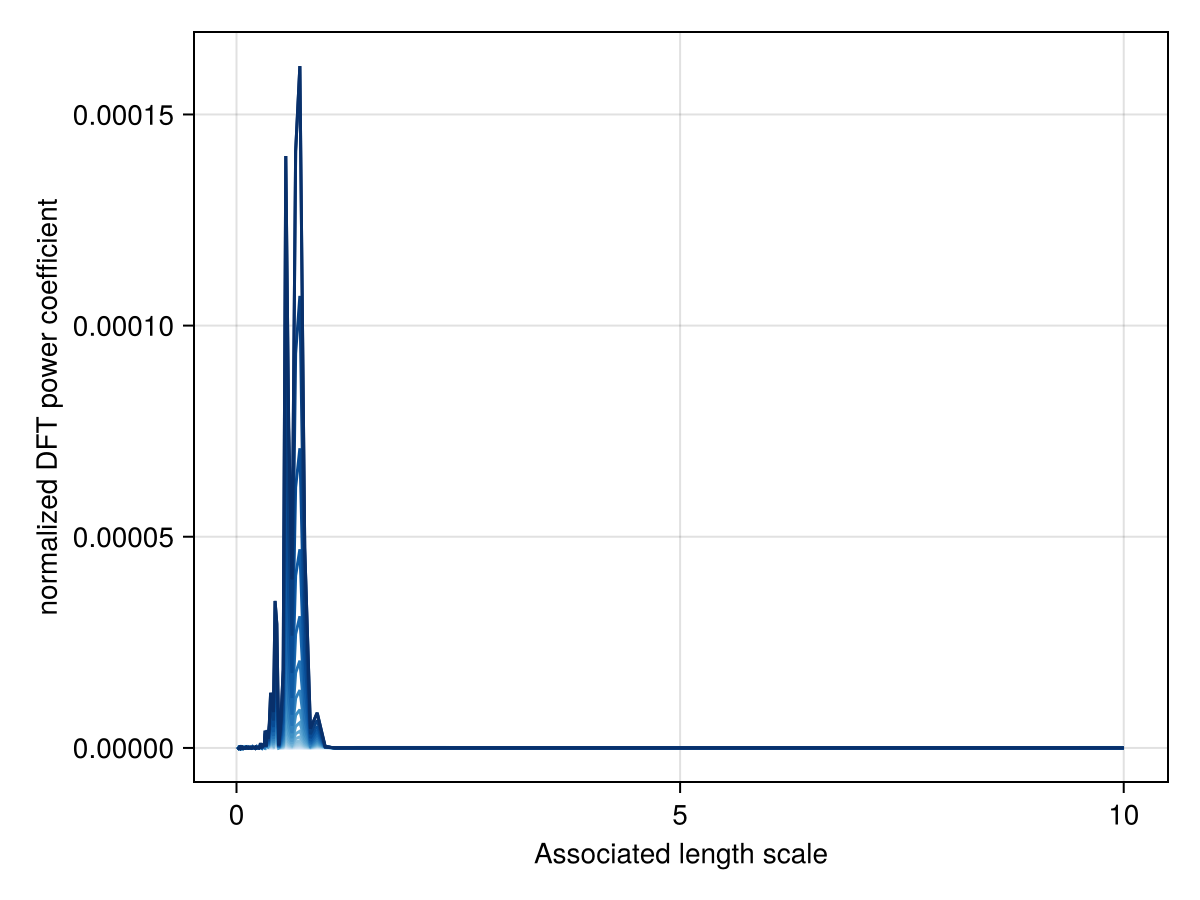

In [201]:
fig = Figure()
ax = Axis(fig[1,1];
    xlabel="Associated length scale",
    ylabel="normalized DFT power coefficient",
)

halfi = div(sN, 2, RoundUp)
freqs = fftfreq(sN, 1. / dx)[2:halfi]

for ti in 1:length(pde_s.t)
# for ti in [length(pde_s.t)]
    f = fft(get_total_biomass_1d(pde_s.u[ti], N))
    sP = abs2.(f[2:halfi]) .* (dx / sN)
    
    lines!(ax, 1 ./ freqs, sP; color=get(ColorSchemes.Blues, pde_s.t[ti] / pde_s.t[end]))
end
# display(GLMakie.Screen(), fig)
fig

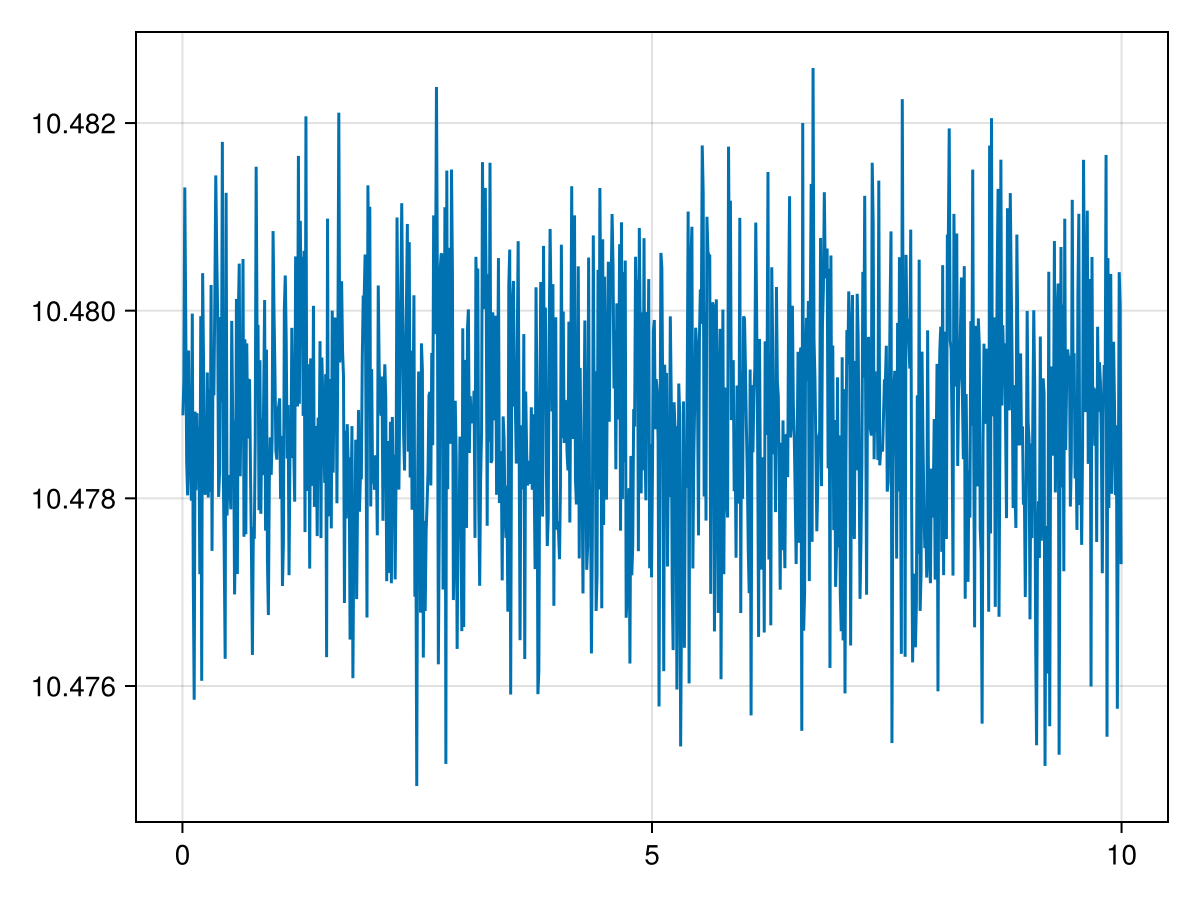

In [165]:
fap = lines(get_spatial_gridpoints_dx(sN, dx), get_total_biomass_1d(pde_s.u[200], N))
# display(GLMakie.Screen(), fap)
fap

In [209]:
get_dominant_lengthscale(get_total_biomass_1d(pde_s.u[end], 1), dx)

0.7142857142857142

In [140]:
fr2_Lmax(rsg.K.value, 1., 1.)

0.3378297626351578

In [107]:
Ls = map(pde_s.u) do u
    get_dominant_lengthscale(get_total_biomass_1d(u, 1), dx)
end;
xx = map(pde_s.u) do u
    sP = get_sP(get_total_biomass_1d(u, 1), dx)
    maximum(sP) / mean(sP)
end;
fap = scatterlines(pde_s.t, Ls;
    # axis=(; xscale=log10)
)
scatterlines!(fap.axis, pde_s.t, xx)
display(GLMakie.Screen(), fap)

GLMakie.Screen(...)

In [145]:
get_spatial_gridpoints_dx(sN, dx)

0.005:0.01:9.995000000000001

extrema(xs) = (0.005, 9.995000000000001)


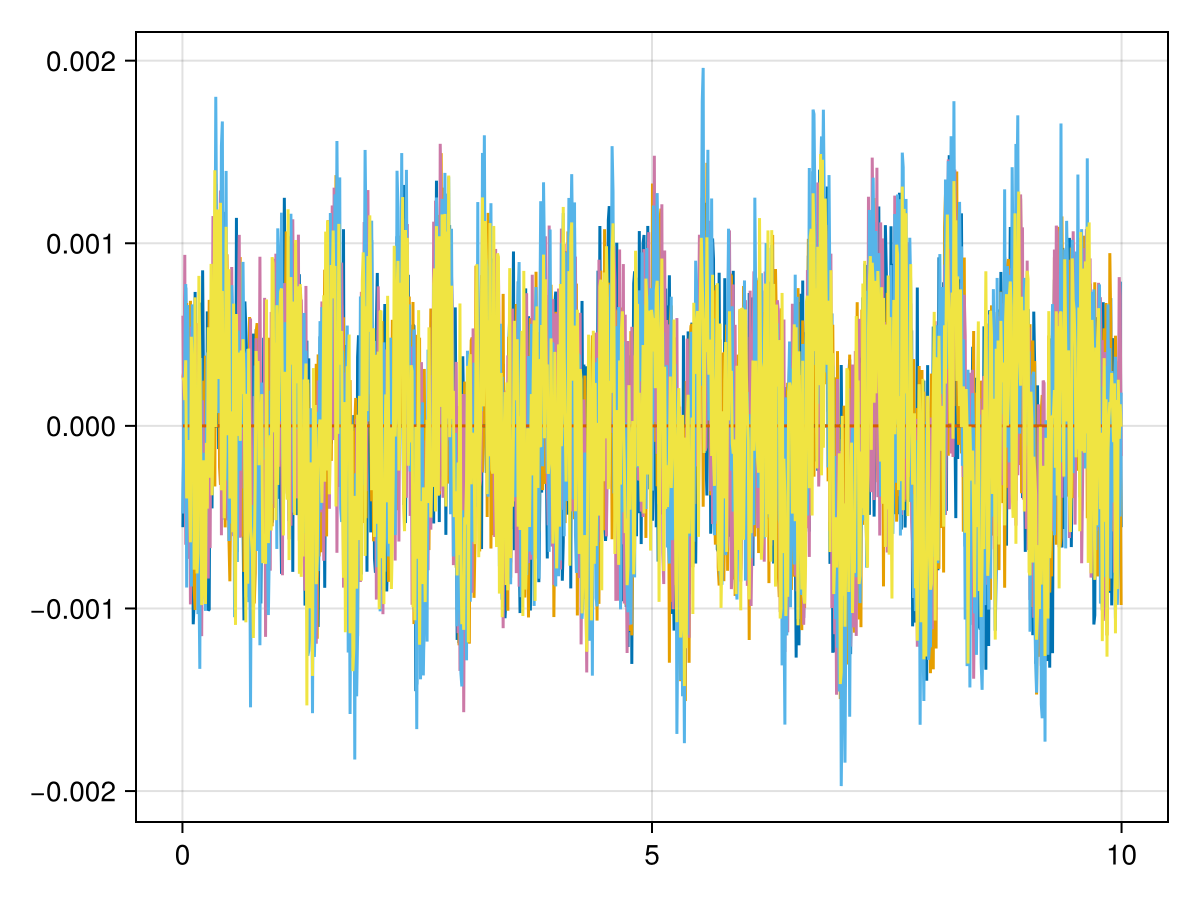

In [ ]:
function plot_spatial_structure_focus(u, Ns, dx, threshold=1000*eps())
    fig = Figure()
    ax = Axis(fig[1,1])
    
    xs = get_spatial_gridpoints_dx(sN, dx)
    @show extrema(xs)

    for i in 1:Ns
        n = @view u[i,:]
        if mean(n) > threshold
            xx = n .- mean(n)
            lines!(ax, xs, xx; label="String $i")
        end
    end
    
    fig
end

# Testing on MM

In [26]:
mmp = MMParams(;
    K=1000.,
    m=1.,
    c=1.,
    l=0.9,
)
T = 1e8
tol = 1e-8

ode_ps = mmp_to_mmicrm(mmp;
    static=false,
)
ode_p = make_mmicrm_problem(ode_ps, [1., 0., 0.], T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 7.733660822850652e-9
ode_s.u[end] = [998.0991885387259, 1.000901623646455, 0.8999098376277002]


In [33]:
DN = 1e-6
DR = 1.

L = 10
sN = 2000

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(1, 2, u0, 1e-3)

# meanN0, numwaves, waveampfactor = 1.0, 100, 100.0
# u0 = get_siny_u0(1, 2, sN, dx, meanN0, numwaves, waveampfactor)

dx = L / sN

pde_ps = BSMMiCRMParams(ode_ps, [DN, 1., DR], CartesianSpace{1, Tuple{Periodic}}([dx]), nthreads())
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    # callback=make_timer_callback(20),
    callback=CallbackSet(make_timer_callback(20), make_fft_callback1(1, sN, dx, 100)),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);
pde_s.retcode

  0.255228 seconds (86.14 k allocations: 317.347 MiB, 2.75% gc time)
smmicrmmaxresid(pde_s) = 2.6432189770275727e-11


ReturnCode.Success = 1

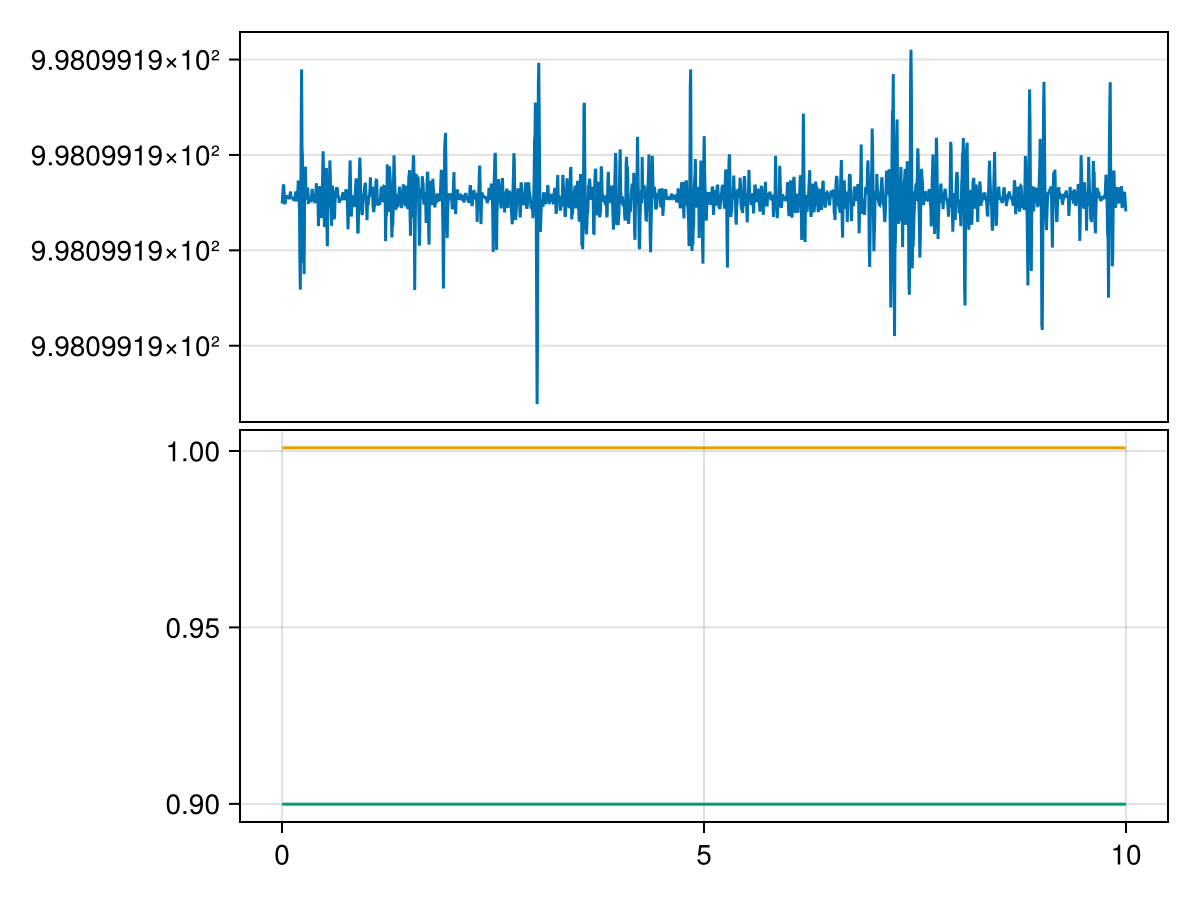

In [35]:
plot_spatial_fs(pde_s.u[end], 1, sN, dx)

In [36]:
get_dominant_lengthscale(get_total_biomass_1d(pde_s.u[end], 1), dx)

0.04149377593360996

In [25]:
fr2_Lmax(get_mmp_beta(mmp), 1., 1.)

0.004450677337047944

In [68]:
Ls = map(pde_s.u) do u
    get_dominant_lengthscale(get_total_biomass_1d(u, 1), dx)
end;
xx = map(pde_s.u) do u
    sP = get_sP(get_total_biomass_1d(u, 1), dx)
    maximum(sP) / mean(sP)
end;
fap = scatterlines(pde_s.t, Ls;
    # axis=(; xscale=log10)
)
scatterlines!(fap.axis, pde_s.t, xx)
display(GLMakie.Screen(), fap)

GLMakie.Screen(...)

In [58]:
function get_sP(ys, dx)
    sN = length(ys)
    f = fft(ys)

    halfi = div(sN, 2, RoundUp)
    sP = abs2.(f[2:halfi]) .* (dx / sN)
end

get_sP (generic function with 1 method)

# Playing around 2

In [4]:
mmp = MMParams(;
    K=15.,
    m=1.,
    c=1.,
    l=1.,
)
T = 1e8
tol = 1e-8

ode_ps = mmp_to_mmicrm(mmp;
    static=false,
)
ode_p = make_mmicrm_problem(ode_ps, [1., 0., 0.], T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 0.0
ode_s.u[end] = [12.922616289332565, 1.0773837106674355, 1.0]


In [5]:
DN = 1e-6
DR = 1.

L = 10
sN = 2000

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(1, 2, u0, 1e-3)

# meanN0, numwaves, waveampfactor = 1.0, 100, 100.0
# u0 = get_siny_u0(1, 2, sN, dx, meanN0, numwaves, waveampfactor)

dx = L / sN

pde_ps = BSMMiCRMParams(ode_ps, [DN, 1., DR], CartesianSpace{1, Tuple{Periodic}}([dx]), nthreads())
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    callback=make_timer_callback(10),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);

 12.088090 seconds (12.30 M allocations: 2.862 GiB, 5.43% gc time, 74.60% compilation time)
smmicrmmaxresid(pde_s) = 1.1204335237380292e-9


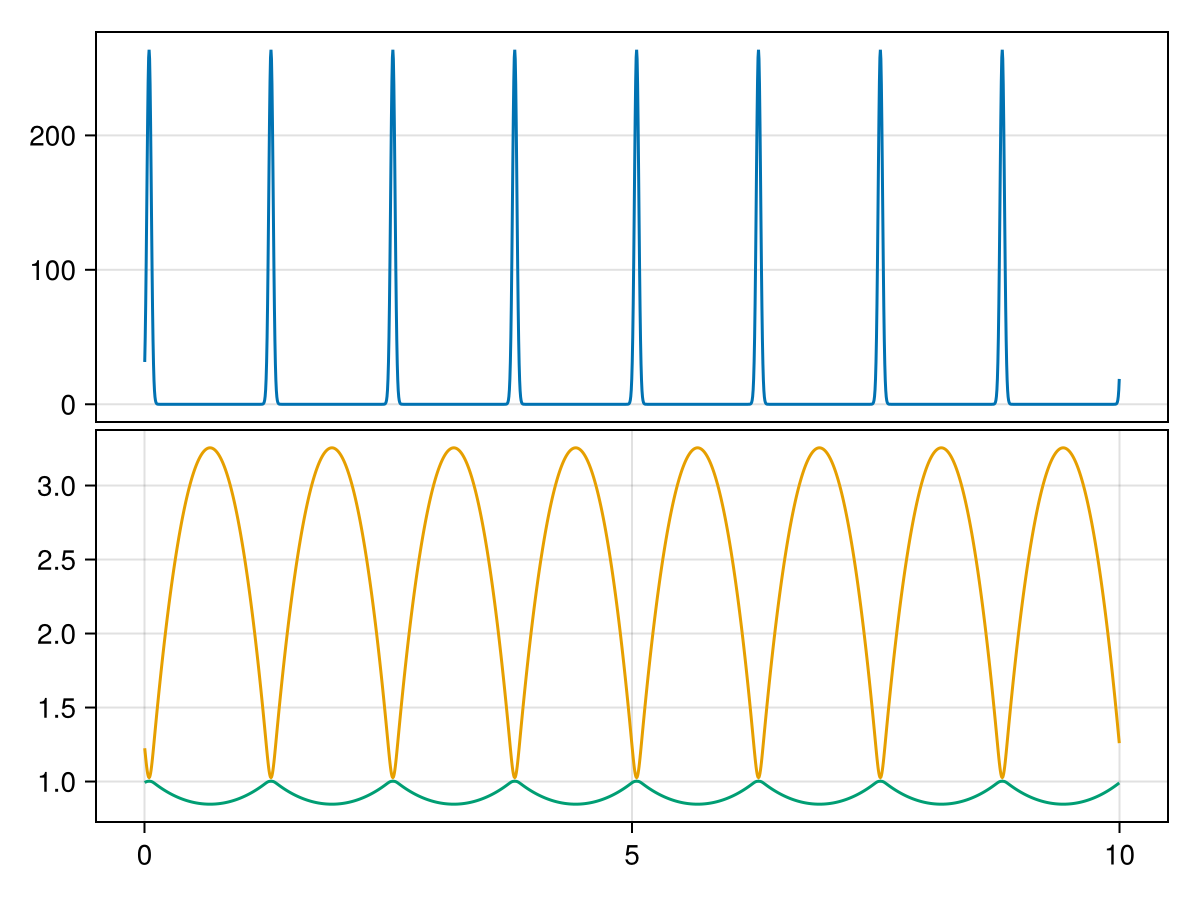

In [6]:
plot_spatial_fs(pde_s.u[end], 1, sN, dx)

In [7]:
s1 = copy(pde_s.u[end][1,:]);

In [8]:
dominant_length_scale(pde_s.u[end][1,:], dx)

LoadError: UndefVarError: `dominant_length_scale` not defined

maximum(Phalf) = 5.3359274149479175e8
mean(Phalf) = 4.1052510507761324e6


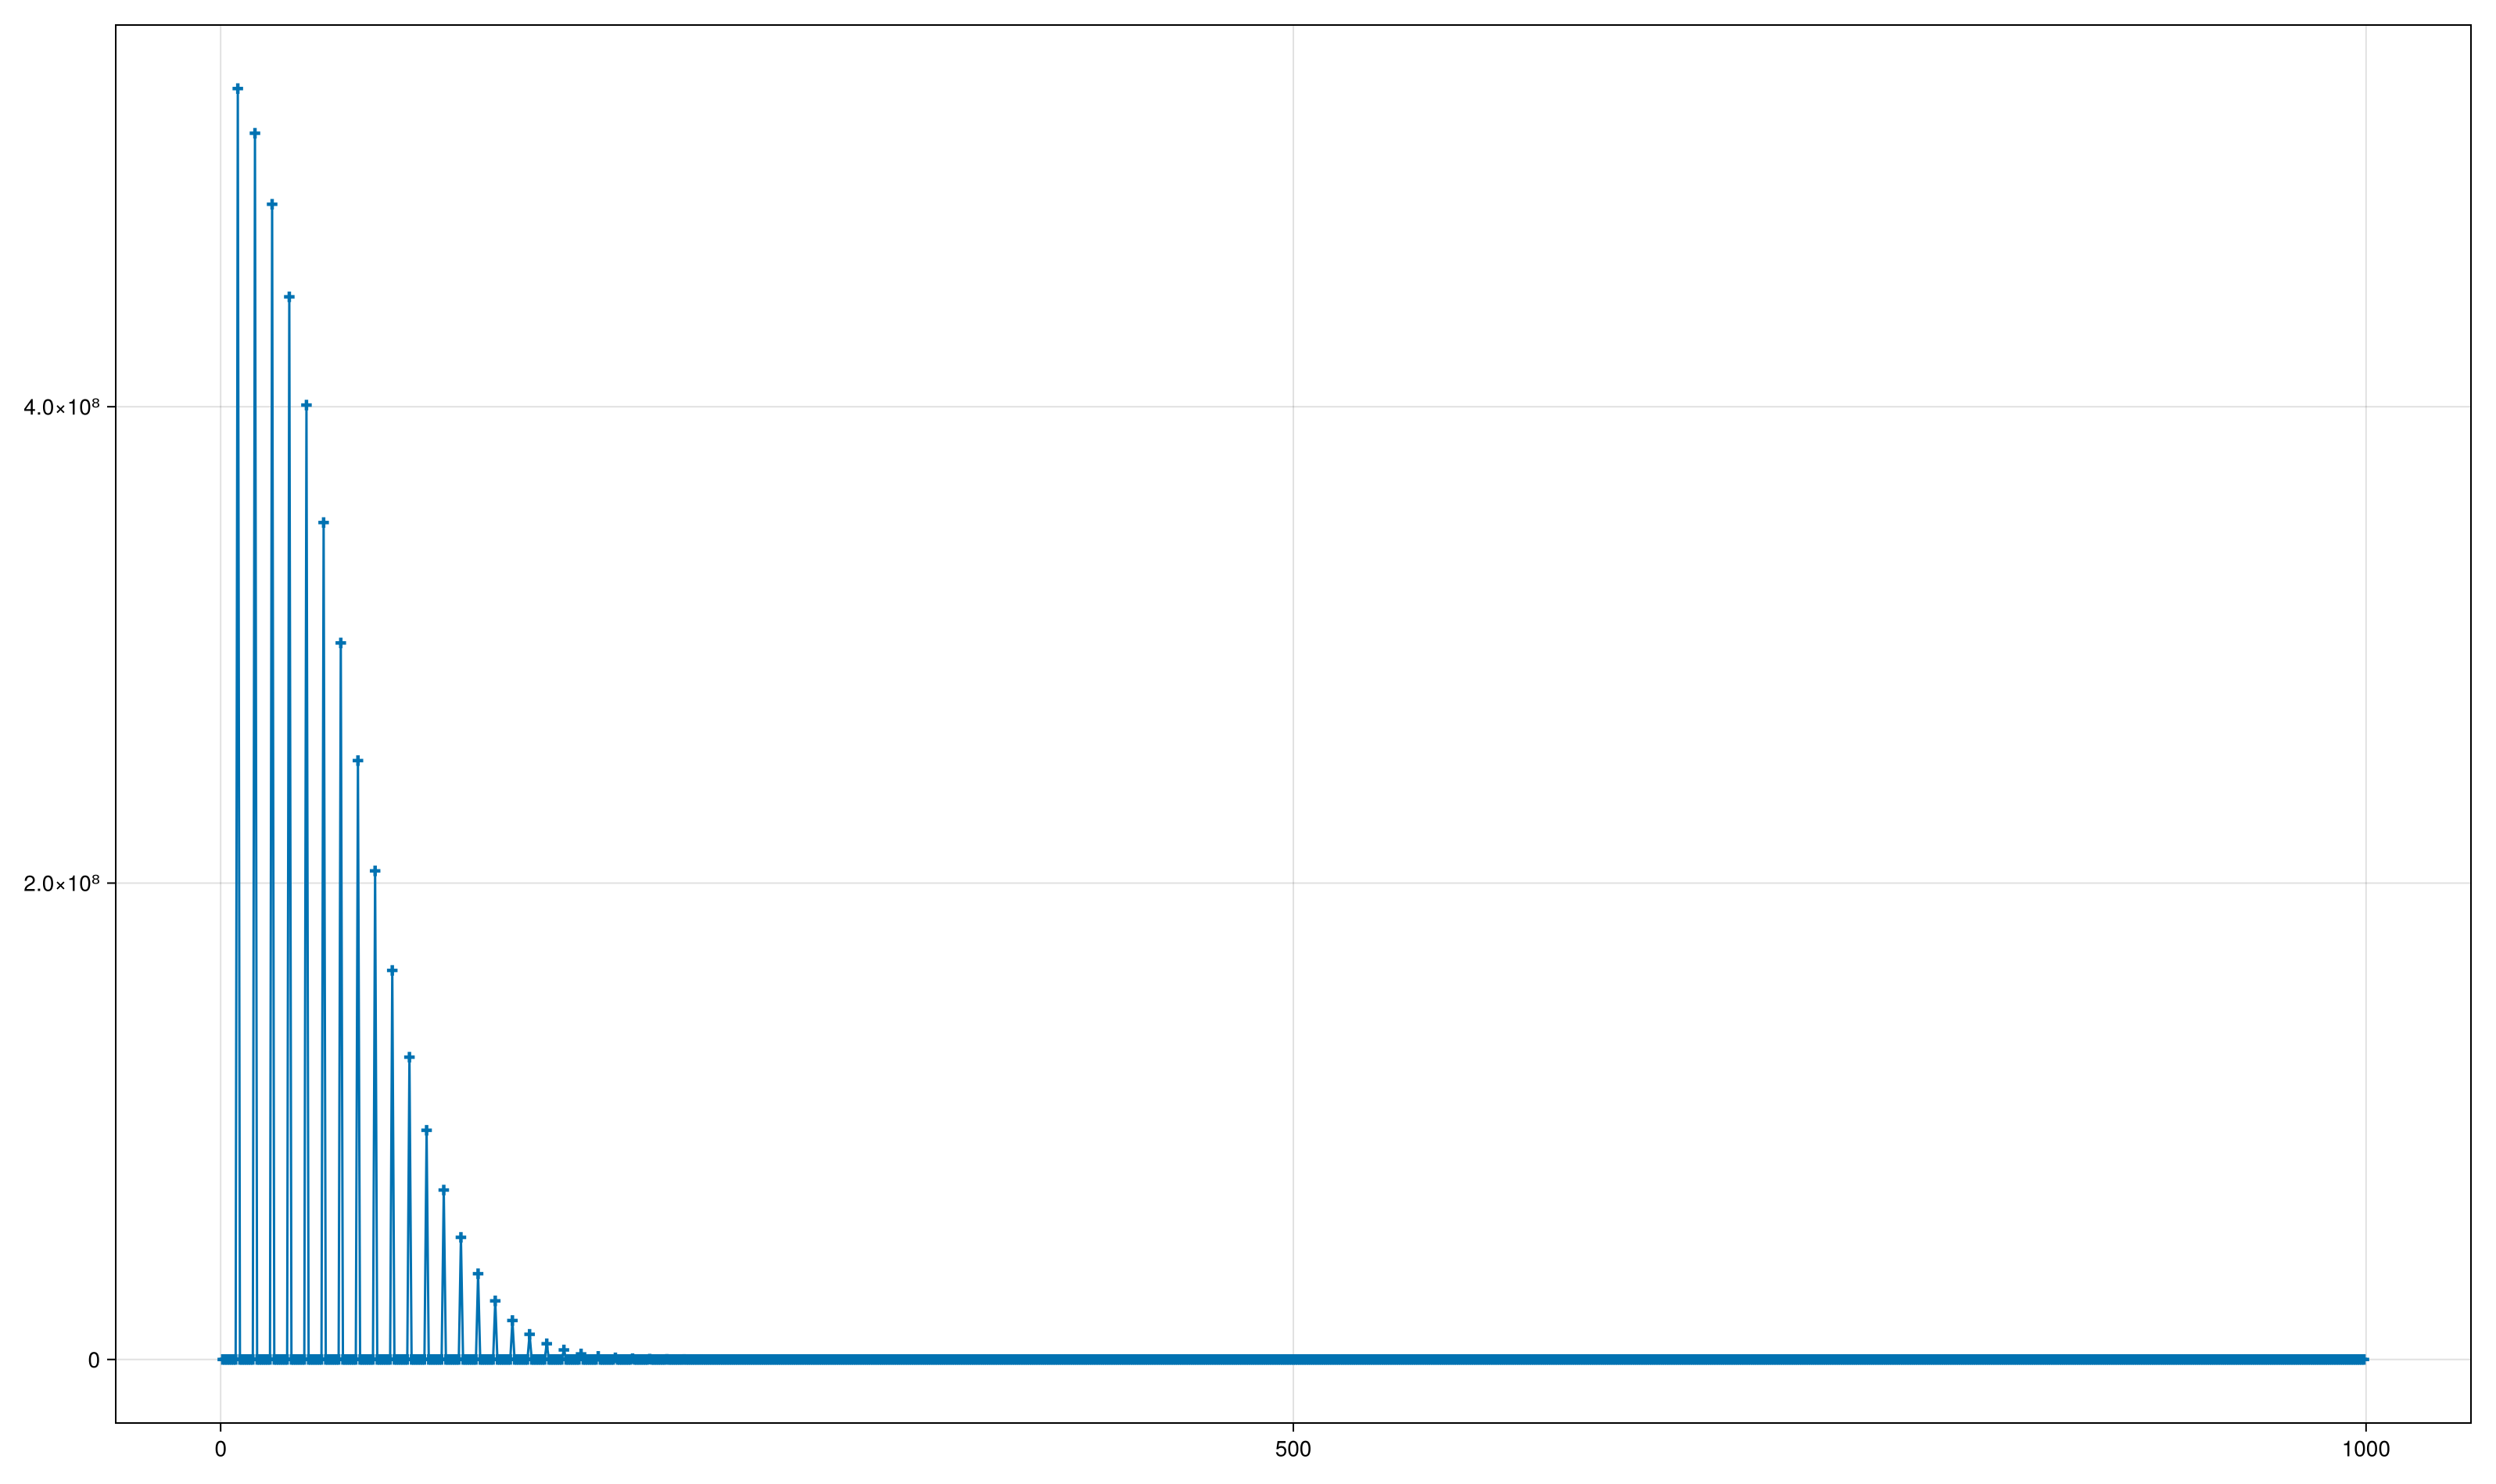

In [228]:
f = fft(pde_s.u[end][1,:])
P = abs2.(f)
Phalf = P[2:div(length(P), 2)]
fap = scatterlines(Phalf; marker=:cross)
display(GLMakie.Screen(), fap)
@show maximum(Phalf) mean(Phalf)
fap

In [215]:
function spatial_structure_test(x, factor=100.)
    P = abs2.(fft(x)[2:div(length(x), 2, RoundUp)])
    maximum(P), mode(P)
end
spatial_structure_test(pde_s.u[1][1,:])

(0.005689062033873677, 0.0003918199979305493)

In [216]:
ma = map(pde_s.u) do x spatial_structure_test(x[1,:], 1.)[1] end
me = map(pde_s.u) do x spatial_structure_test(x[1,:], 1.)[2] end;

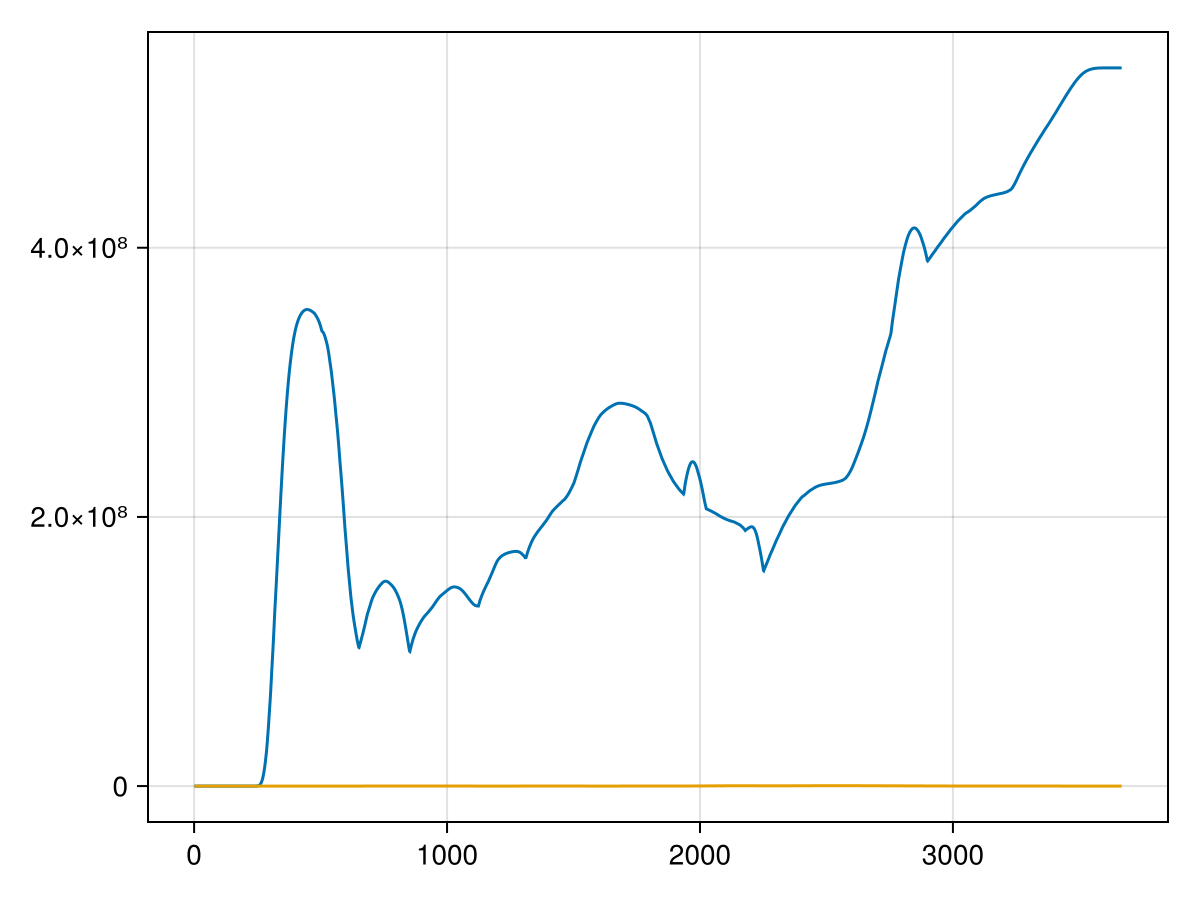

In [218]:
fap = lines(ma)
lines!(fap.axis, me)
# display(GLMakie.Screen(), fap)
fap

In [191]:
xx = hcat(map(pde_s.u) do fs
    abs2.(fft(fs[1,:])[2:div(size(fs, 2), 2, RoundUp)])
end...);

# Playing around

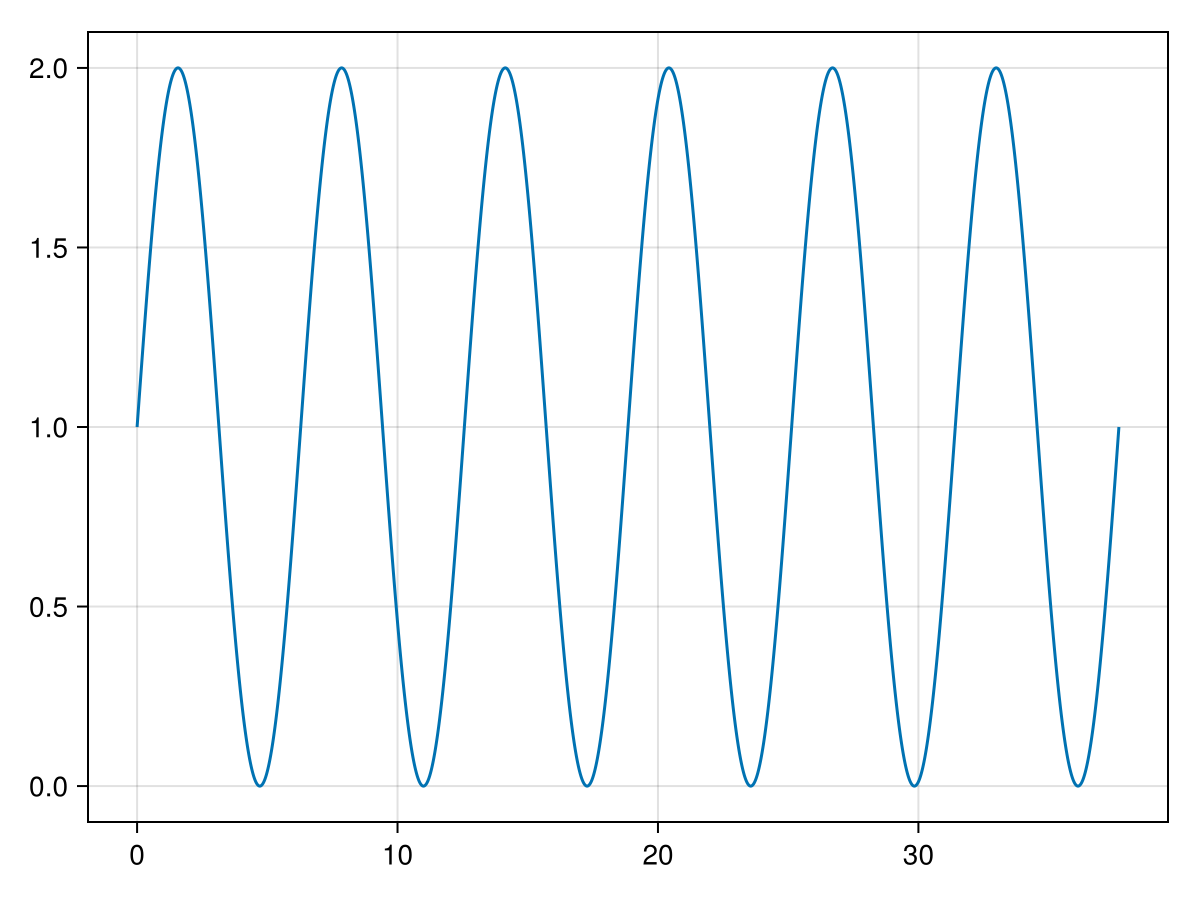

In [23]:
N = 10000
xs = range(0, 12*pi, N)
dx = xs[2] - xs[1]
ys = map(xs) do x
    sin(x)
end
ys .+= 1.
# ys = zeros(length(xs))
# ys[1:100:N] .= 1.
lines(xs, ys)

In [26]:
using SSMCMain

In [31]:
f = fft(ys)
# P = abs2.(f) ./ N^2
P = abs2.(f) .* (dx / N)

halfi = div(N, 2, RoundUp)
sP = P[2:halfi]

Pmax, iPmax = findmax(sP)

@show P[1], P[halfi - 5]
@show (Pmax, mean(sP), mode(sP), Pmax / mean(sP))

dom_f = fftfreq(N, 1 / dx)[iPmax+1]
dom_f, 1 / dom_f

(P[1], P[halfi - 5]) = (37.70288213129065, 1.3398810094070185e-12)
(Pmax, mean(sP), mode(sP), Pmax / mean(sP)) = (9.424766770485215, 0.0018853326586854807, 1.1077662295059066e-8, 4998.994064557545)


(0.15913902759758616, 6.283813688548441)

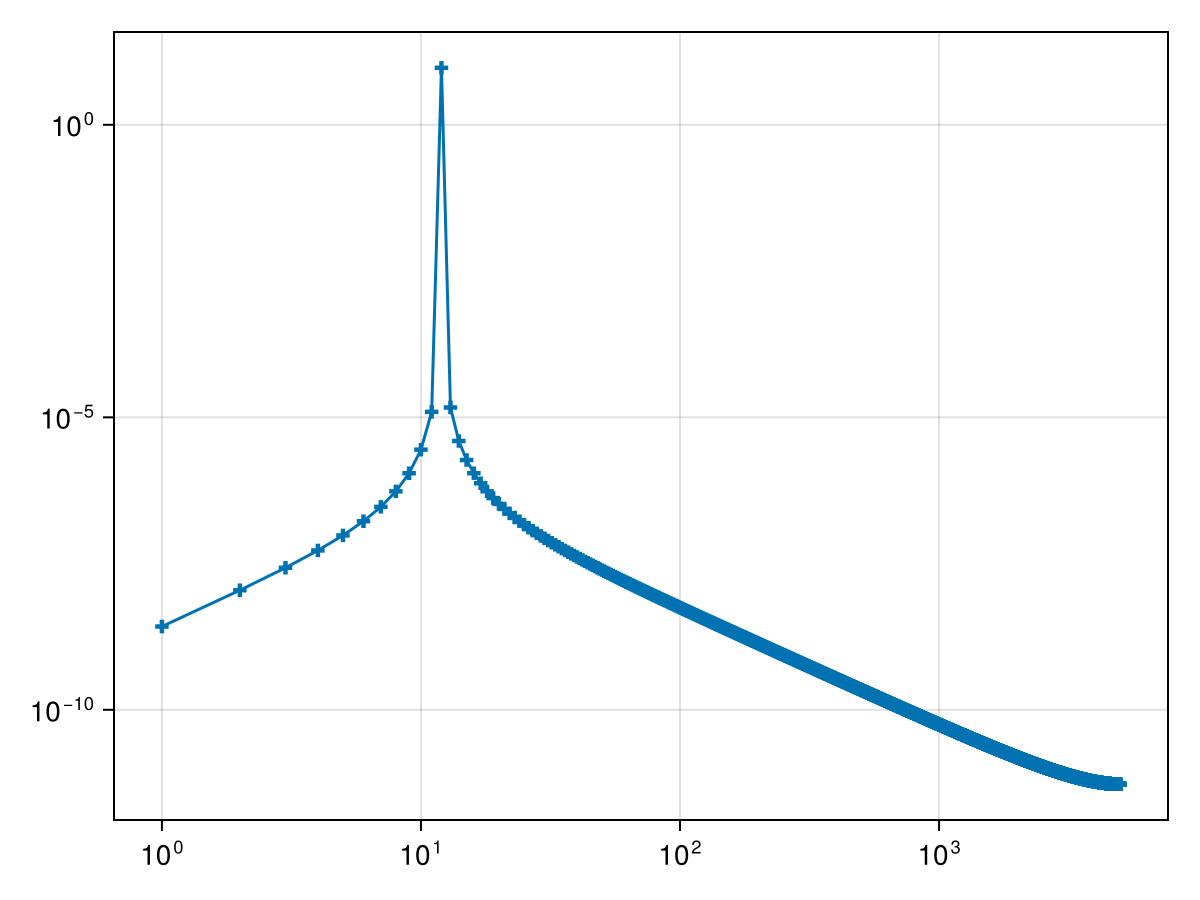

In [20]:
fap = scatterlines(sP; marker=:cross, axis=(; yscale=log10, xscale=log10))

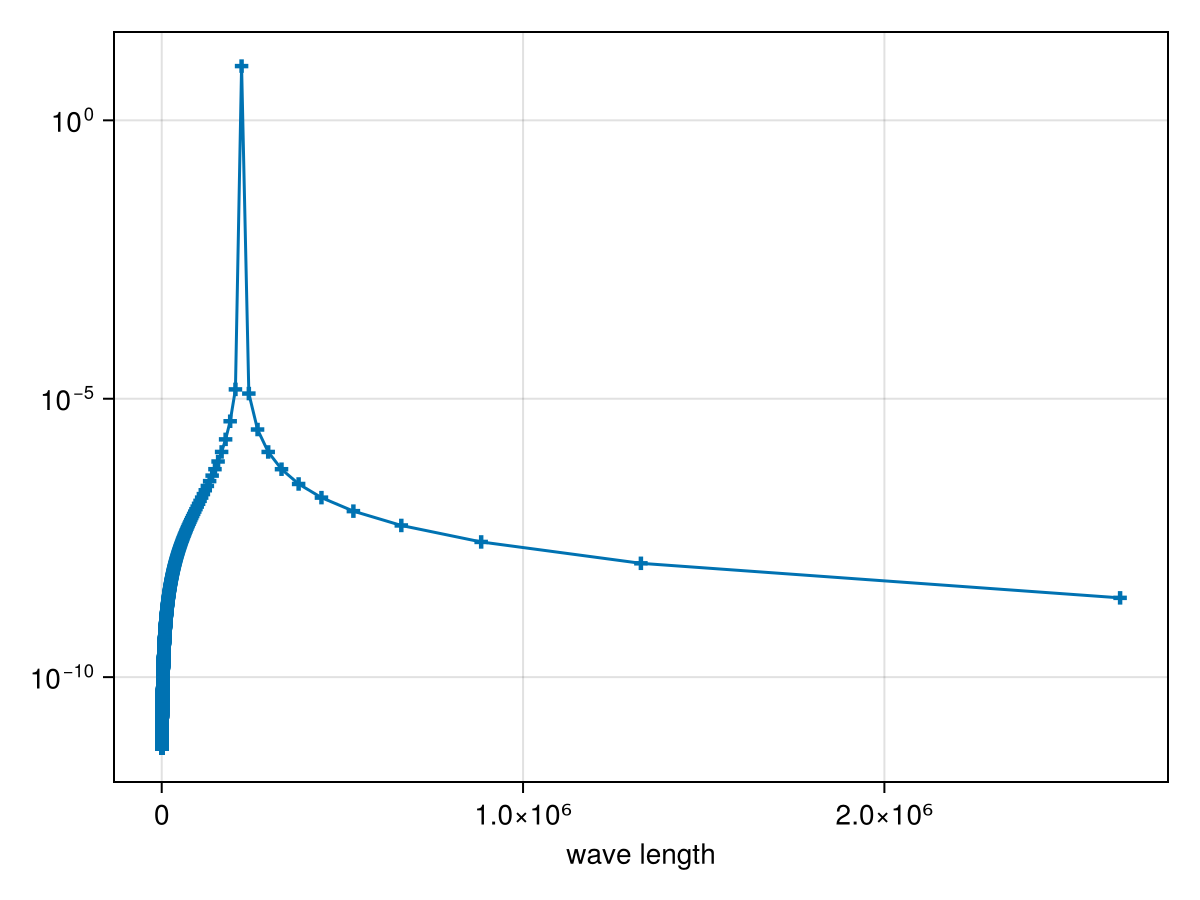

In [130]:
fap = scatterlines(1 ./ fftfreq(N, dx)[2:halfi], P[2:halfi]; marker=:cross, axis=(; yscale=log10, xlabel="wave length"))

In [21]:
dominant_length_scale(ys, dx)

(3.1419068442742204, 0.3182780551951723)

In [14]:
using FFTW
using Statistics

"""
    dominant_length_scale(signal, dx; window=false, detrend=true)

Compute the dominant length scale of a 1D spatial signal using a Fourier transform.

# Arguments
- `signal::AbstractVector`: spatial data
- `dx::Real`: spacing between points

# Keywords
- `window::Bool=false`: apply Hann window to reduce spectral leakage
- `detrend::Bool=true`: subtract mean before FFT

# Returns
- `λ_dom`: dominant wavelength
- `k_dom`: dominant frequency (cycles per unit length)
"""
function dominant_length_scale(signal, dx; window=false, detrend=true)

    N = length(signal)
    s = copy(signal)

    # --- Detrend ---
    if detrend
        s .-= mean(s)
    end

    # --- Windowing ---
    if window
        # simple Hann window without extra packages
        w = 0.5 .*(1 .- cos.(2π .* (0:N-1) ./ (N-1)))
        s .= s .* w
    end

    # --- FFT ---
    F = fft(s)

    # --- Frequencies (cycles per unit length) ---
    k = fftfreq(N, 1/dx)

    # --- Power spectrum ---
    P = abs.(F).^2

    # Remove zero-frequency component
    P[1] = 0

    # Only positive frequencies
    half = div(N, 2)
    k_pos = k[1:half]
    P_pos = P[1:half]

    # --- Find dominant frequency ---
    i_max = argmax(P_pos)
    k_dom = k_pos[i_max]

    # Convert to wavelength
    λ_dom = 1 / k_dom

    return λ_dom, k_dom
end

dominant_length_scale

# Playing around 3

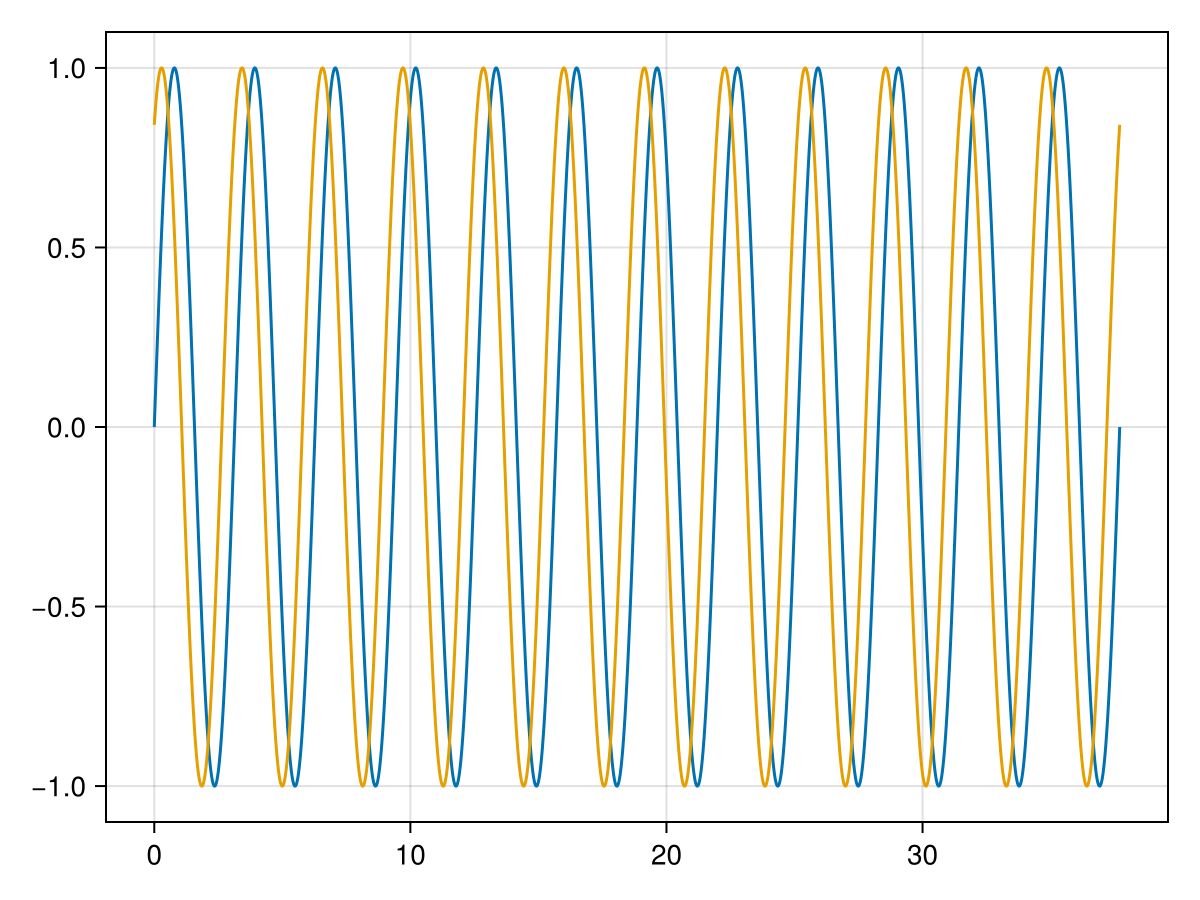

In [153]:
N = 10000
xs = range(0, 12*pi, N)
dx = xs[2] - xs[1]
ys = Matrix{Float64}(undef, 2, N)
ys[1,:] .= sin.(2 .* xs)
ys[2,:] .= sin.(2 .* xs .+ 1.)
fap = lines(xs, ys[1,:])
lines!(xs, ys[2,:])
fap

In [164]:
f = fft(ys, (2,))
P = abs2.(f) .* (dx / N)

halfi = div(N, 2, RoundUp)
sP = P[:,2:halfi]

2×4999 Matrix{Float64}:
 2.65444e-9  1.10776e-8  2.68046e-8  5.30059e-8  …  5.35955e-12  5.35954e-12
 2.71485e-7  2.85668e-7  3.11563e-7  3.53333e-7     1.56459e-12  1.56459e-12

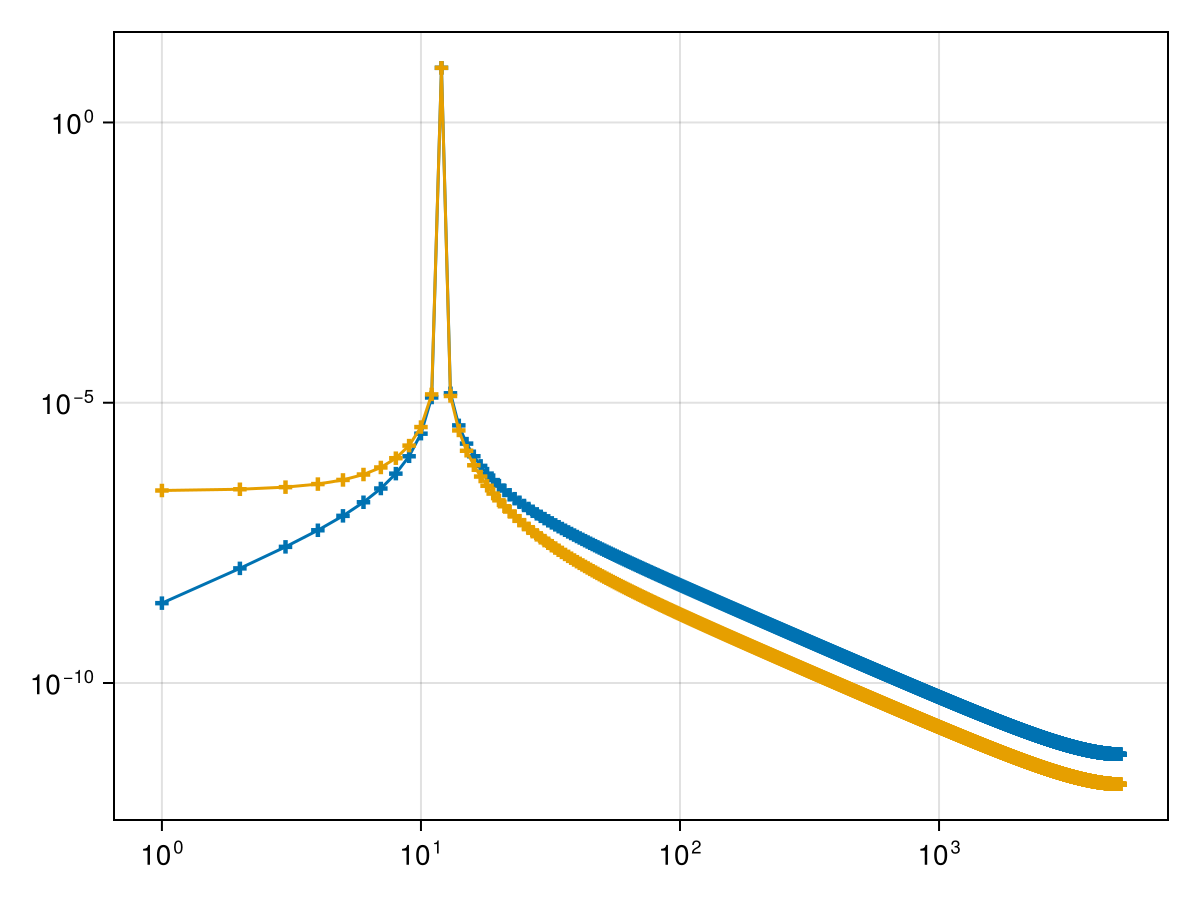

In [165]:
fap = scatterlines(sP[1,:]; marker=:cross, axis=(; yscale=log10, xscale=log10))
scatterlines!(fap.axis, sP[2,:]; marker=:cross)
fap

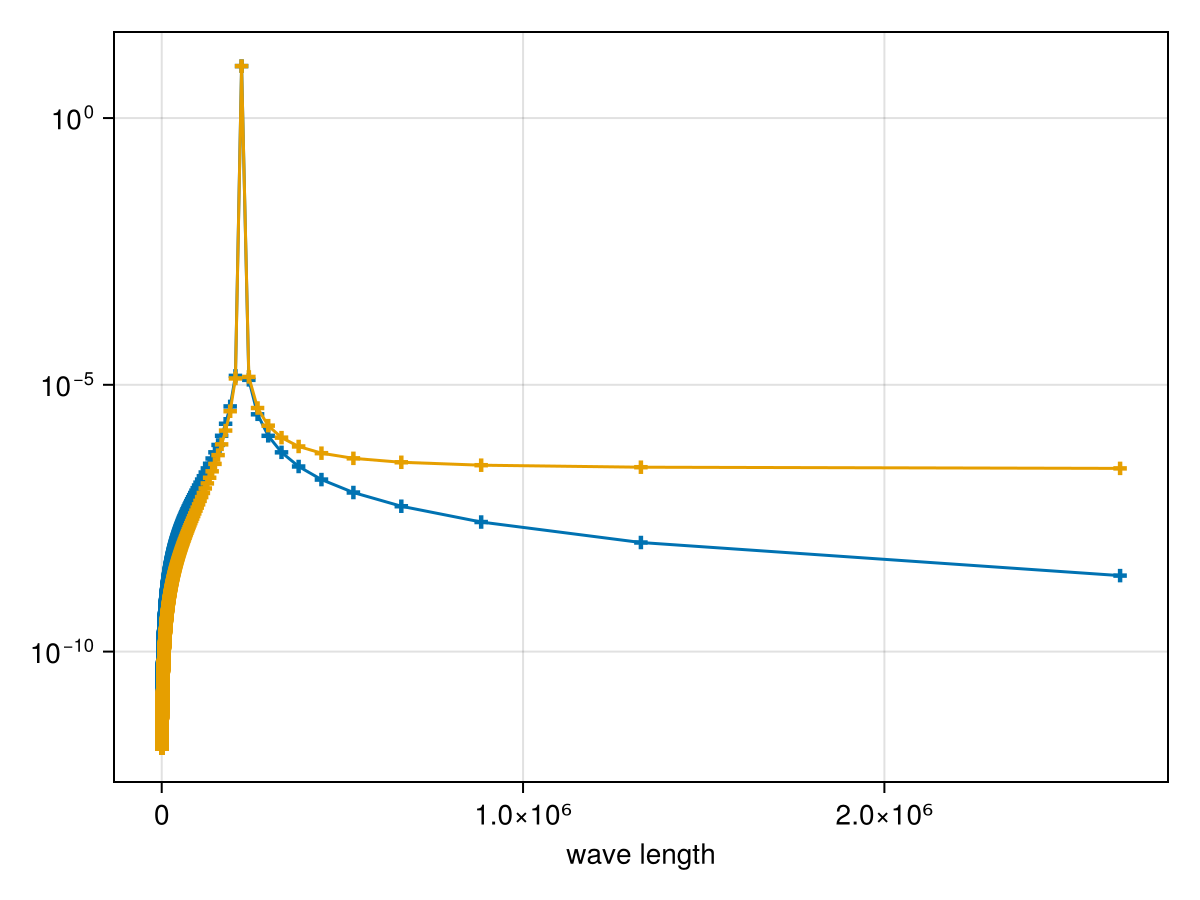

In [166]:
fap = scatterlines(1 ./ fftfreq(N, dx)[2:halfi], sP[1,:]; marker=:cross, axis=(; yscale=log10, xlabel="wave length"))
scatterlines!(fap.axis, 1 ./ fftfreq(N, dx)[2:halfi], sP[2,:]; marker=:cross)
fap